# Trader Performance vs Market Sentiment Analysis

### Primetrade.ai – Data Science Intern Assignment



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load the Datasets

In [2]:
fear = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

print("Fear Greed Dataset Shape:", fear.shape)
print("Trader Dataset Shape:", trader.shape)

Fear Greed Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [3]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Clean Column Names



In [10]:
fear.columns = fear.columns.str.strip().str.replace(" ", "_")
trader.columns = trader.columns.str.strip().str.replace(" ", "_")

print(fear.columns)
print(trader.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution_Price', 'Size_Tokens', 'Size_USD', 'Side',
       'Timestamp_IST', 'Start_Position', 'Direction', 'Closed_PnL',
       'Transaction_Hash', 'Order_ID', 'Crossed', 'Fee', 'Trade_ID',
       'Timestamp'],
      dtype='object')


## Data Quality Checks

We examine:

- Missing values
- Duplicate rows
- Data types

In [5]:
print("Fear Greed Missing Values")
print(fear.isnull().sum())

print("\nTrader Missing Values")
print(trader.isnull().sum())

Fear Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
print("Fear duplicates:", fear.duplicated().sum())
print("Trader duplicates:", trader.duplicated().sum())

Fear duplicates: 0
Trader duplicates: 0


## Timestamp Conversion

We convert timestamps into proper datetime format and extract the **date** for merging the datasets.

In [12]:
fear['date'] = pd.to_datetime(fear['date'])

trader['Timestamp_IST'] = pd.to_datetime(
    trader['Timestamp_IST'],
    dayfirst=True
)

trader['date'] = trader['Timestamp_IST'].dt.date
trader['date'] = pd.to_datetime(trader['date'])

## Merge Trader Data with Market Sentiment

In [13]:
merged = trader.merge(
    fear[['date','classification']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution_Price,Size_Tokens,Size_USD,Side,Timestamp_IST,Start_Position,Direction,Closed_PnL,Transaction_Hash,Order_ID,Crossed,Fee,Trade_ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


## Feature Engineering

Create useful metrics for analysis.

In [14]:
merged['trade_value'] = merged['Execution_Price'] * merged['Size_Tokens']

In [15]:
trades_per_day = merged.groupby('date').size()

trades_per_day.head()

,0
date,
2023-05-01,3
2023-12-05,9
2023-12-14,11
2023-12-15,2
2023-12-16,3


In [16]:
merged['win'] = merged['Closed_PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean()

win_rate

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


In [17]:
merged['win'] = merged['Closed_PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean()

win_rate

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


In [18]:
long_short = merged['Side'].value_counts()

long_short

,count
Side,
SELL,108528
BUY,102696


## Analysis: Trader Performance vs Sentiment

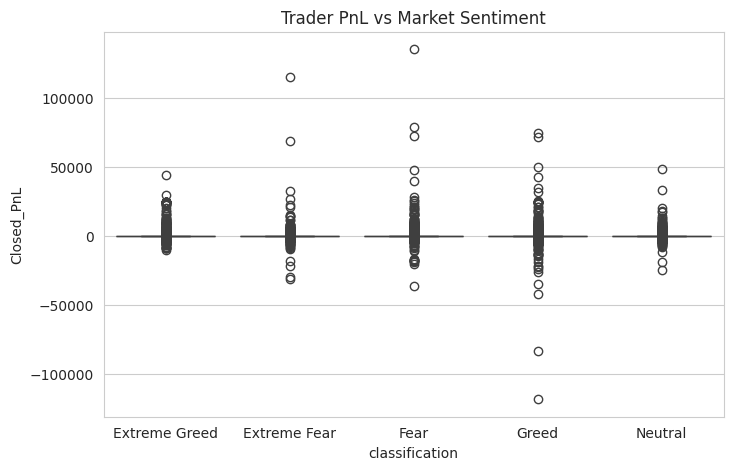

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed_PnL',
    data=merged
)

plt.title("Trader PnL vs Market Sentiment")
plt.savefig("pnl_vs_sentiment.png")
plt.show()

/tmp/ipykernel_1691/578873113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


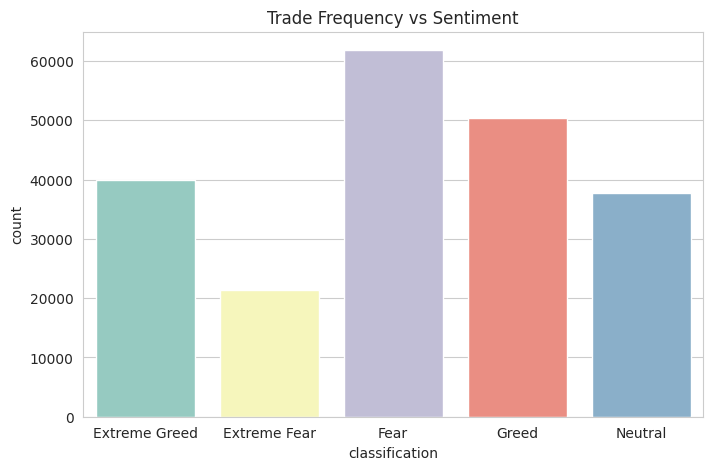

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='classification',
    data=merged, palette='Set3'
)

plt.title("Trade Frequency vs Sentiment")
plt.savefig("trade_frequency.png")
plt.show()

/tmp/ipykernel_1691/2202664921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


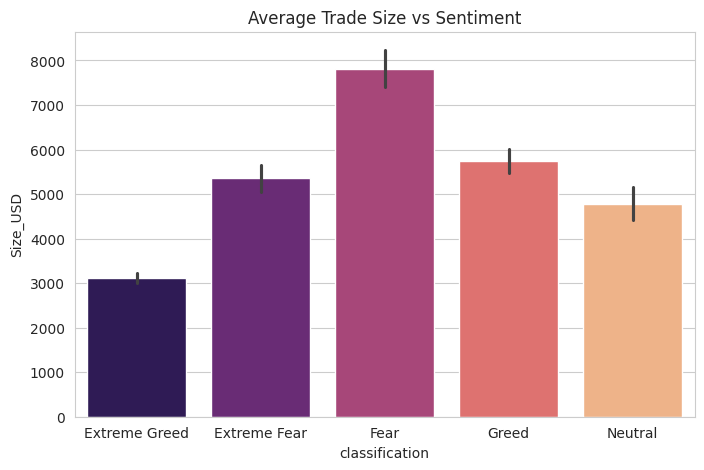

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='Size_USD',
    data=merged, palette='magma'
)

plt.title("Average Trade Size vs Sentiment")
plt.savefig("trade_size.png")
plt.show()

## Trader Segmentation

In [28]:
trade_counts = merged.groupby('Account').size()

median_trades = trade_counts.median()

merged['trader_type'] = merged['Account'].map(
    lambda x: "Frequent" if trade_counts[x] > median_trades else "Infrequent"
)

In [29]:
trader_pnl = merged.groupby('Account')['Closed_PnL'].mean()

median_pnl = trader_pnl.median()

merged['pnl_group'] = merged['Account'].map(
    lambda x: "High PnL" if trader_pnl[x] > median_pnl else "Low PnL"
)

## Bonus: Trader Behavior Clustering

In [30]:
from sklearn.cluster import KMeans

features = merged[['Size_USD','Closed_PnL']].fillna(0)

kmeans = KMeans(n_clusters=3)

merged['cluster'] = kmeans.fit_predict(features)

merged[['Account','cluster']].head()

,Account,cluster
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0


# Methodology
We combined the Fear & Greed sentiment dataset with historical trader data by aligning both datasets on the daily timestamp.

Key steps included:
- Data cleaning and preprocessing
- Timestamp conversion and alignment
- Feature engineering (PnL, trade frequency, trade size)
- Sentiment-based analysis of trader behavior
- Segmentation of traders based on activity and profitability

# Key Insights
1. Trader profitability shows variation across market sentiment conditions.

2. Trading activity tends to increase during Greed periods, suggesting higher market participation.

3. Frequent traders exhibit higher volatility in PnL compared to infrequent traders.

# Strategy Recommendations
1. During Fear market sentiment, traders should reduce position size to limit downside risk.

2. During Greed sentiment periods, traders may increase trade frequency to capture momentum-driven opportunities.

3. Risk management is critical for high-frequency traders due to higher PnL volatility.

## Conclusion

This analysis explored how market sentiment influences trader behavior.

Key findings:

- Trading activity increases during Greed sentiment.
- Trader profitability varies depending on market conditions.
- Segmentation helps identify trader behavior patterns.

These insights can inform improved trading strategies and risk management.